### PACOTES

In [52]:

import matplotlib.pyplot as plt
import pandas as pd
import time

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import umap.umap_ as umap

### Importar e separar o csv

In [37]:
# 1 Carregar o arquivo CSV
df = pd.read_csv('2x2visu_scores.csv')

# 2 Ordenar pelo score_Final de forma decrescente e pegar os 3 primeiros
top_5 = df.nlargest(5, 'Score_Final')

# 3 Extrair os valores da coluna 'Features'
features_list = top_10['Features'].tolist()

# 4 Separar em variáveis (
feature_top1 = features_list[0]
feature_top2 = features_list[1]
feature_top3 = features_list[2]
feature_top4 = features_list[3]
feature_top5 = features_list[4]

x1, y1 = feature_top1.split('|')
x2, y2 = feature_top2.split('|')
x3, y3 = feature_top3.split('|')
x4, y4 = feature_top4.split('|')
x5, y5 = feature_top5.split('|')

# Limpando espaços em branco extras, se houver
x1 = x1.strip()
y1 = y1.strip()

x2 = x2.strip()
y2 = y2.strip()
 
x3 = x3.strip()
y3 = y3.strip()

x4 = x4.strip()
y4 = y4.strip()

x5 = x5.strip()
y5 = y5.strip()
 
print(f"Top 1 Feature Completa: {feature_top1}")
print(f"Variável x1: {x1}")
print(f"Variável y1: {y1}")

print(f"Top 2 Feature Completa: {feature_top2}")
print(f"Variável x2: {x2}")
print(f"Variável y2: {y2}")

print(f"Top 3 Feature Completa: {feature_top3}")
print(f"Variável x3: {x3}")
print(f"Variável y4: {y3}")

print(f"Top 4 Feature Completa: {feature_top4}")
print(f"Variável x5: {x4}")
print(f"Variável y5: {y4}")

print(f"Top 5 Feature Completa: {feature_top5}")
print(f"Variável x6: {x5}")
print(f"Variável y6: {y5}")


Top 1 Feature Completa: V10 | V14
Variável x1: V10
Variável y1: V14
Top 2 Feature Completa: V12 | V14
Variável x2: V12
Variável y2: V14
Top 3 Feature Completa: V10 | V11
Variável x3: V10
Variável y4: V11
Top 4 Feature Completa: V14 | V17
Variável x5: V14
Variável y5: V17
Top 5 Feature Completa: V11 | V17
Variável x6: V11
Variável y6: V17


### Primeiro Lugar

### ORIGINAL


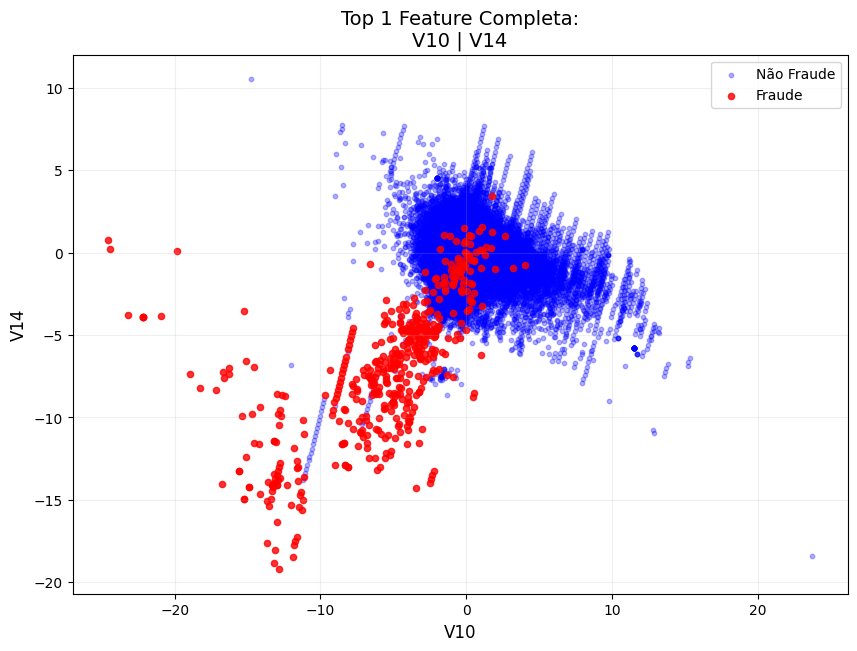

In [38]:
posicao_rank = 1
# CASO df NÃO ESTEJA CARREGADO
df = pd.read_csv('creditcard.csv')

# GRÁFICO 2D
plt.figure(figsize=(10, 7))

# NÃO FRAUDE
plt.scatter(

    df[df['status_fraude'] == 0][x1],
    df[df['status_fraude'] == 0][y1],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df[df['status_fraude'] == 1][x1],
    df[df['status_fraude'] == 1][y1],

    color='red',
    alpha=0.8,
    s=20,
    label='Fraude'

)

# TÍTULO
plt.title(
    f'Top 1 Feature Completa:\n{feature_top1}',
    fontsize=14
)

plt.xlabel(x1, fontsize=12)
plt.ylabel(y1, fontsize=12)

# LEGENDA
plt.legend()

# GRID
plt.grid(alpha=0.2)

# SHOW
plt.show()

### T-SNE


Top 1: V10 | V14
X = V10
Y = V14


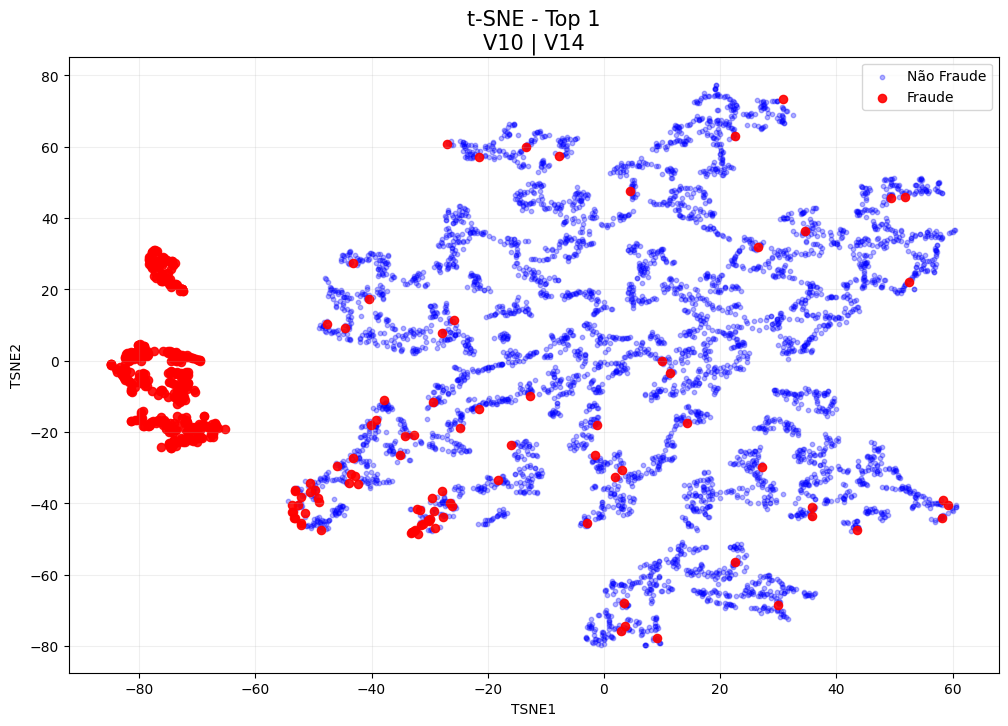

In [39]:
df_rank = pd.read_csv('2x2visu_scores.csv')

# =========================================================
# PEGAR FEATURE DA POSIÇÃO ESCOLHIDA
# =========================================================

feature_escolhida = df_rank.iloc[
    posicao_rank - 1
]['Features']

# =========================================================
# EXTRAIR FEATURES
# =========================================================

x1, y1 = feature_escolhida.split('|')

x1 = x1.strip()
y1 = y1.strip()

# =========================================================
# PRINT
# =========================================================

print(f'\nTop {posicao_rank}: {feature_escolhida}')
print(f'X = {x1}')
print(f'Y = {y1}')

# =========================================================
# DATASET
# =========================================================

df = pd.read_csv('creditcard.csv')

# =========================================================
# FRAUDES
# =========================================================

fraudes = df[
    df['status_fraude'] == 1
]

# =========================================================
# SAMPLE NÃO FRAUDES
# =========================================================

nao_fraudes = df[
    df['status_fraude'] == 0
].sample(

    n=5000,
    random_state=42

)

# =========================================================
# CONCATENAR
# =========================================================

df_tsne = pd.concat([

    fraudes,
    nao_fraudes

])

# =========================================================
# FEATURES
# =========================================================

X = df_tsne[[x1, y1]]

y = df_tsne['status_fraude']

# =========================================================
# ESCALONAMENTO
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================================================
# TSNE
# =========================================================

tsne = TSNE(

    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42

)

X_tsne = tsne.fit_transform(X_scaled)

# =========================================================
# DATAFRAME FINAL
# =========================================================

df_plot = pd.DataFrame({

    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Fraude': y.values

})

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(12, 8))

# NÃO FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE2'],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE2'],

    color='red',
    alpha=0.9,
    s=35,
    label='Fraude'

)

# =========================================================
# TÍTULO
# =========================================================

plt.title(

    f't-SNE - Top {posicao_rank}\n'
    f'{feature_escolhida}',

    fontsize=15

)

plt.xlabel('TSNE1')
plt.ylabel('TSNE2')

# =========================================================
# LEGENDA
# =========================================================

plt.legend()

# =========================================================
# GRID
# =========================================================

plt.grid(alpha=0.2)

# =========================================================
# SHOW
# =========================================================

plt.show()

### Segundo Lugar

### ORIGINAL


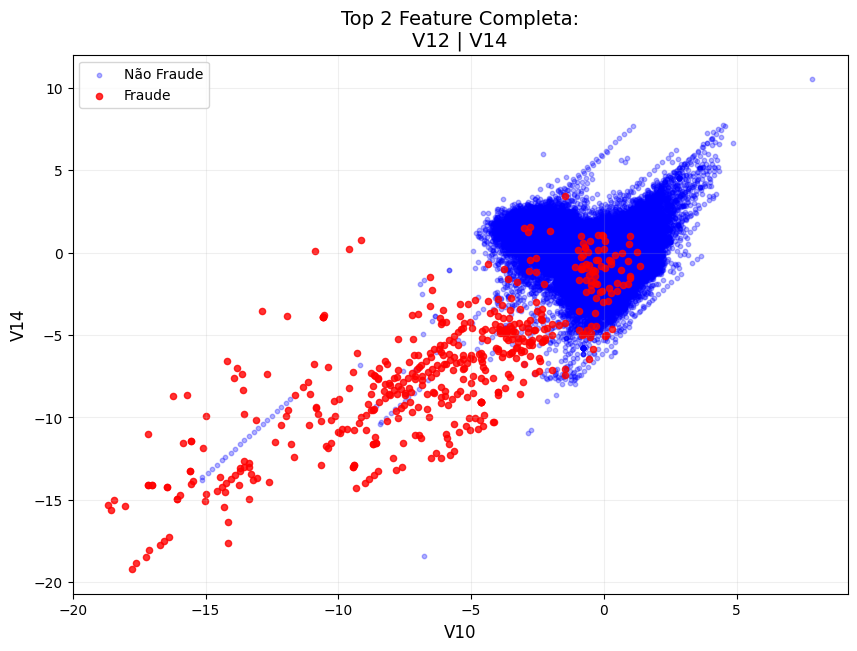

In [40]:
posicao_rank = 2
# GRÁFICO 2D
plt.figure(figsize=(10, 7))

# NÃO FRAUDE
plt.scatter(

    df[df['status_fraude'] == 0][x2],
    df[df['status_fraude'] == 0][y2],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df[df['status_fraude'] == 1][x2],
    df[df['status_fraude'] == 1][y2],

    color='red',
    alpha=0.8,
    s=20,
    label='Fraude'

)

# TÍTULO
plt.title(
    f'Top 2 Feature Completa:\n{feature_top2}',
    fontsize=14
)

plt.xlabel(x1, fontsize=12)
plt.ylabel(y1, fontsize=12)

# LEGENDA
plt.legend()

# GRID
plt.grid(alpha=0.2)


# SHOW
plt.show()

### T-SNE


Top 2: V12 | V14
X = V12
Y = V14


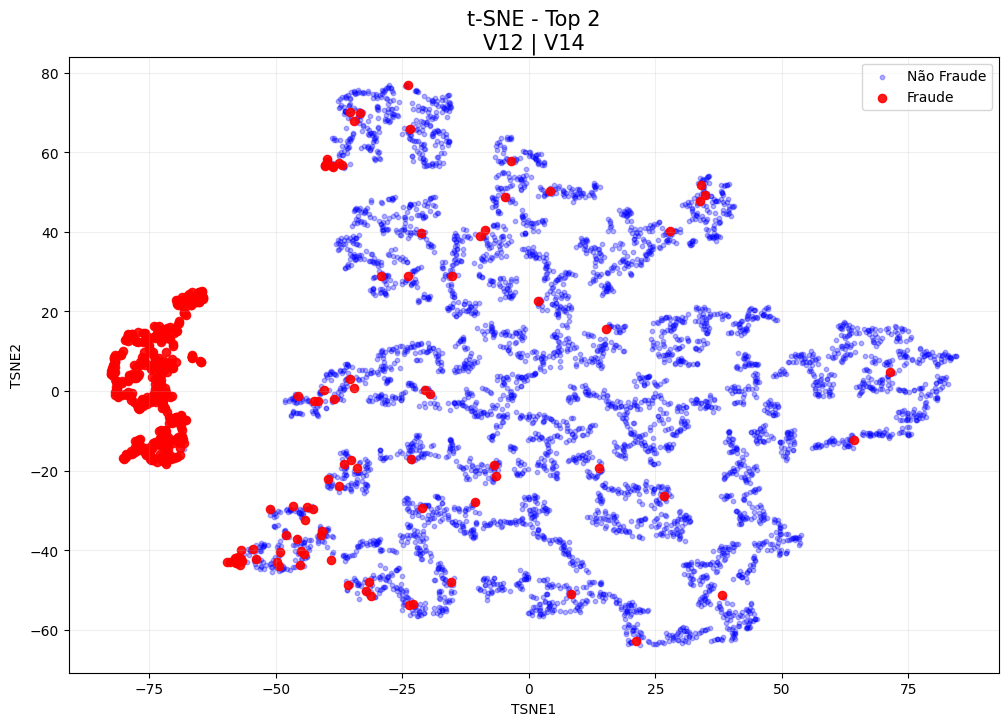

In [41]:

posicao_rank = 2

# =========================================================
# CARREGAR RANKING
# =========================================================

df_rank = pd.read_csv('2x2visu_scores.csv')

# =========================================================
# PEGAR FEATURE DA POSIÇÃO ESCOLHIDA
# =========================================================

feature_escolhida = df_rank.iloc[
    posicao_rank - 1
]['Features']

# =========================================================
# EXTRAIR FEATURES
# =========================================================

x1, y1 = feature_escolhida.split('|')

x1 = x1.strip()
y1 = y1.strip()

# =========================================================
# PRINT
# =========================================================

print(f'\nTop {posicao_rank}: {feature_escolhida}')
print(f'X = {x1}')
print(f'Y = {y1}')

# =========================================================
# DATASET
# =========================================================

df = pd.read_csv('creditcard.csv')

# =========================================================
# FRAUDES
# =========================================================

fraudes = df[
    df['status_fraude'] == 1
]

# =========================================================
# SAMPLE NÃO FRAUDES
# =========================================================

nao_fraudes = df[
    df['status_fraude'] == 0
].sample(

    n=5000,
    random_state=42

)

# =========================================================
# CONCATENAR
# =========================================================

df_tsne = pd.concat([

    fraudes,
    nao_fraudes

])

# =========================================================
# FEATURES
# =========================================================

X = df_tsne[[x1, y1]]

y = df_tsne['status_fraude']

# =========================================================
# ESCALONAMENTO
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================================================
# TSNE
# =========================================================

tsne = TSNE(

    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42

)

X_tsne = tsne.fit_transform(X_scaled)

# =========================================================
# DATAFRAME FINAL
# =========================================================

df_plot = pd.DataFrame({

    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Fraude': y.values

})

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(12, 8))

# NÃO FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE2'],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE2'],

    color='red',
    alpha=0.9,
    s=35,
    label='Fraude'

)

# =========================================================
# TÍTULO
# =========================================================

plt.title(

    f't-SNE - Top {posicao_rank}\n'
    f'{feature_escolhida}',

    fontsize=15

)

plt.xlabel('TSNE1')
plt.ylabel('TSNE2')

# =========================================================
# LEGENDA
# =========================================================

plt.legend()

# =========================================================
# GRID
# =========================================================

plt.grid(alpha=0.2)

# =========================================================
# SHOW
# =========================================================

plt.show()

### Terceiro Lugar

### ORIGINAL


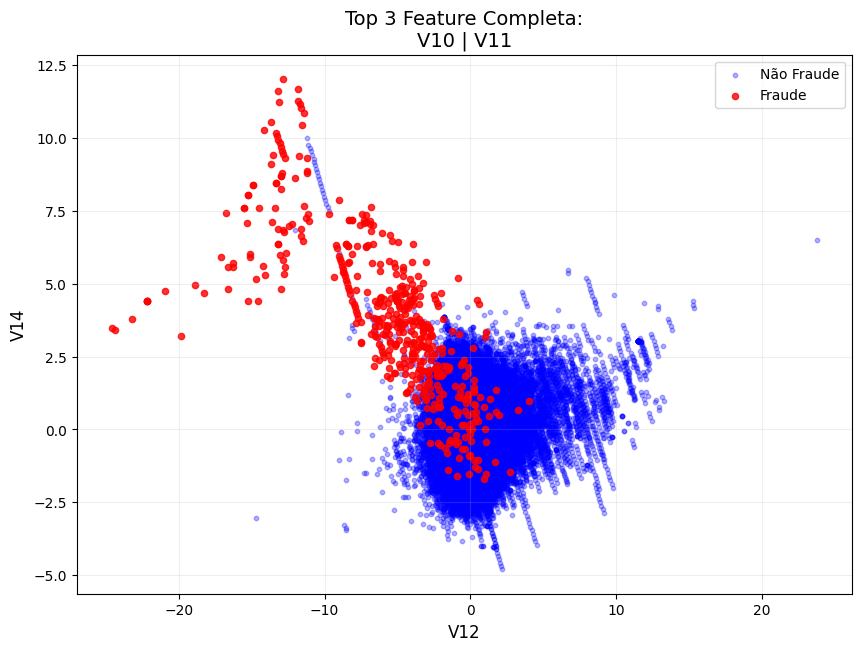

In [42]:
posicao_rank = 3

# GRÁFICO 2D
plt.figure(figsize=(10, 7))

# NÃO FRAUDE
plt.scatter(

    df[df['status_fraude'] == 0][x3],
    df[df['status_fraude'] == 0][y3],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df[df['status_fraude'] == 1][x3],
    df[df['status_fraude'] == 1][y3],

    color='red',
    alpha=0.8,
    s=20,
    label='Fraude'

)


# TÍTULO
plt.title(
    f'Top 3 Feature Completa:\n{feature_top3}',
    fontsize=14
)

plt.xlabel(x1, fontsize=12)
plt.ylabel(y1, fontsize=12)

# LEGENDA
plt.legend()

# GRID
plt.grid(alpha=0.2)

# SHOW
plt.show()

### T-SNE


Top 3: V10 | V11
X = V10
Y = V11


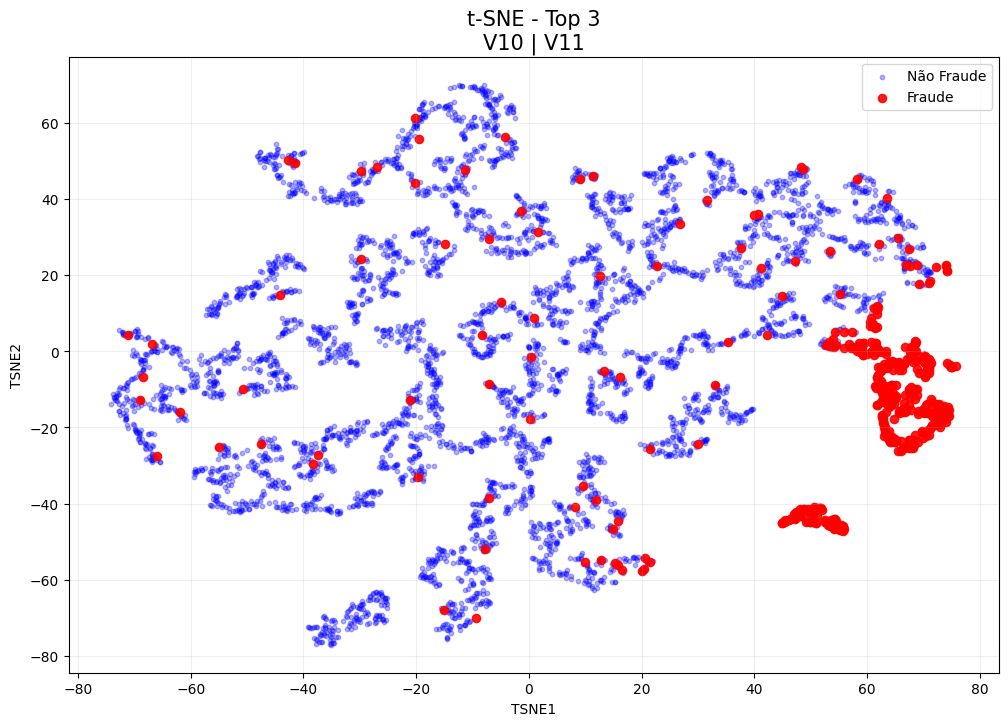

In [43]:

posicao_rank = 3

# =========================================================
# CARREGAR RANKING
# =========================================================

df_rank = pd.read_csv('2x2visu_scores.csv')

# =========================================================
# PEGAR FEATURE DA POSIÇÃO ESCOLHIDA
# =========================================================

feature_escolhida = df_rank.iloc[
    posicao_rank - 1
]['Features']

# =========================================================
# EXTRAIR FEATURES
# =========================================================

x1, y1 = feature_escolhida.split('|')

x1 = x1.strip()
y1 = y1.strip()

# =========================================================
# PRINT
# =========================================================

print(f'\nTop {posicao_rank}: {feature_escolhida}')
print(f'X = {x1}')
print(f'Y = {y1}')

# =========================================================
# DATASET
# =========================================================

df = pd.read_csv('creditcard.csv')

# =========================================================
# FRAUDES
# =========================================================

fraudes = df[
    df['status_fraude'] == 1
]

# =========================================================
# SAMPLE NÃO FRAUDES
# =========================================================

nao_fraudes = df[
    df['status_fraude'] == 0
].sample(

    n=5000,
    random_state=42

)

# =========================================================
# CONCATENAR
# =========================================================

df_tsne = pd.concat([

    fraudes,
    nao_fraudes

])

# =========================================================
# FEATURES
# =========================================================

X = df_tsne[[x1, y1]]

y = df_tsne['status_fraude']

# =========================================================
# ESCALONAMENTO
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================================================
# TSNE
# =========================================================

tsne = TSNE(

    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42

)

X_tsne = tsne.fit_transform(X_scaled)

# =========================================================
# DATAFRAME FINAL
# =========================================================

df_plot = pd.DataFrame({

    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Fraude': y.values

})

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(12, 8))

# NÃO FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE2'],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE2'],

    color='red',
    alpha=0.9,
    s=35,
    label='Fraude'

)

# =========================================================
# TÍTULO
# =========================================================

plt.title(

    f't-SNE - Top {posicao_rank}\n'
    f'{feature_escolhida}',

    fontsize=15

)

plt.xlabel('TSNE1')
plt.ylabel('TSNE2')

# =========================================================
# LEGENDA
# =========================================================

plt.legend()

# =========================================================
# GRID
# =========================================================

plt.grid(alpha=0.2)

# =========================================================
# SHOW
# =========================================================

plt.show()

### Quarto Lugar

### ORIGINAL

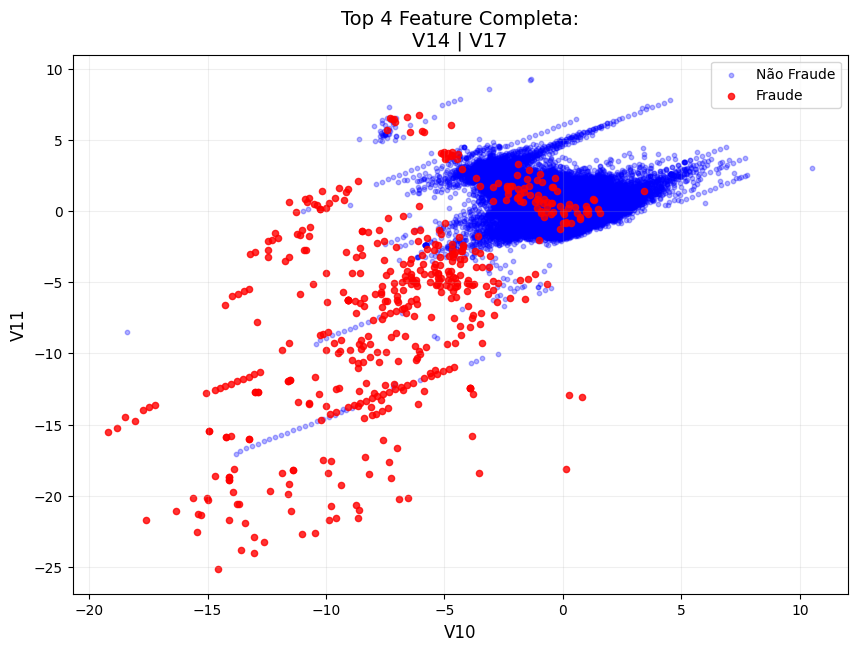

In [44]:
posicao_rank = 4
# GRÁFICO 2D
plt.figure(figsize=(10, 7))

# NÃO FRAUDE
plt.scatter(

    df[df['status_fraude'] == 0][x4],
    df[df['status_fraude'] == 0][y4],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df[df['status_fraude'] == 1][x4],
    df[df['status_fraude'] == 1][y4],

    color='red',
    alpha=0.8,
    s=20,
    label='Fraude'

)

# TÍTULO
plt.title(
    f'Top 4 Feature Completa:\n{feature_top4}',
    fontsize=14
)

plt.xlabel(x1, fontsize=12)
plt.ylabel(y1, fontsize=12)

# LEGENDA
plt.legend()

# GRID
plt.grid(alpha=0.2)

# SHOW
plt.show()

### T-SNE


Top 4: V14 | V17
X = V14
Y = V17


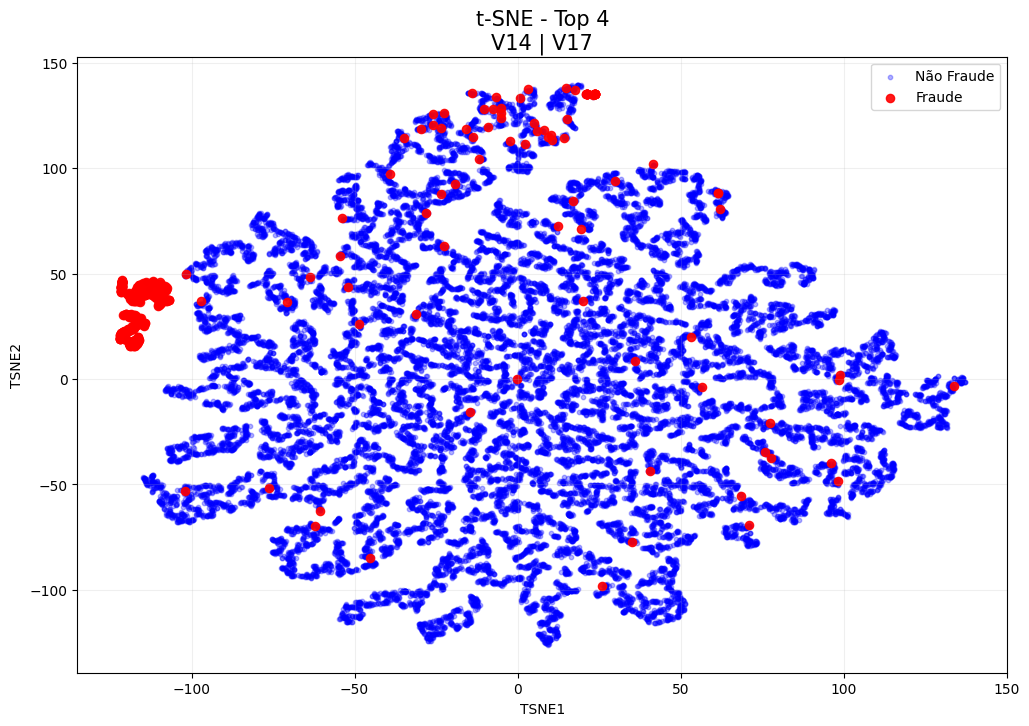

In [55]:

posicao_rank = 4

# =========================================================
# CARREGAR RANKING
# =========================================================

df_rank = pd.read_csv('2x2visu_scores.csv')

# =========================================================
# PEGAR FEATURE DA POSIÇÃO ESCOLHIDA
# =========================================================

feature_escolhida = df_rank.iloc[
    posicao_rank - 1
]['Features']

# =========================================================
# EXTRAIR FEATURES
# =========================================================

x1, y1 = feature_escolhida.split('|')

x1 = x1.strip()
y1 = y1.strip()

# =========================================================
# PRINT
# =========================================================

print(f'\nTop {posicao_rank}: {feature_escolhida}')
print(f'X = {x1}')
print(f'Y = {y1}')

# =========================================================
# DATASET
# =========================================================

df = pd.read_csv('creditcard.csv')

# =========================================================
# FRAUDES
# =========================================================

fraudes = df[
    df['status_fraude'] == 1
]

# =========================================================
# SAMPLE NÃO FRAUDES
# =========================================================

nao_fraudes = df[
    df['status_fraude'] == 0
].sample(

    n=30000,
    random_state=42

)

# =========================================================
# CONCATENAR
# =========================================================

df_tsne = pd.concat([

    fraudes,
    nao_fraudes

])

# =========================================================
# FEATURES
# =========================================================

X = df_tsne[[x1, y1]]

y = df_tsne['status_fraude']

# =========================================================
# ESCALONAMENTO
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================================================
# TSNE
# =========================================================

tsne = TSNE(

    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42

)

X_tsne = tsne.fit_transform(X_scaled)

# =========================================================
# DATAFRAME FINAL
# =========================================================

df_plot = pd.DataFrame({

    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Fraude': y.values

})

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(12, 8))

# NÃO FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE2'],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE2'],

    color='red',
    alpha=0.9,
    s=35,
    label='Fraude'

)

# =========================================================
# TÍTULO
# =========================================================

plt.title(

    f't-SNE - Top {posicao_rank}\n'
    f'{feature_escolhida}',

    fontsize=15

)

plt.xlabel('TSNE1')
plt.ylabel('TSNE2')

# =========================================================
# LEGENDA
# =========================================================

plt.legend()

# =========================================================
# GRID
# =========================================================

plt.grid(alpha=0.2)

# =========================================================
# SHOW
# =========================================================

plt.show()

### Quinto Lugar

### ORIGINAL

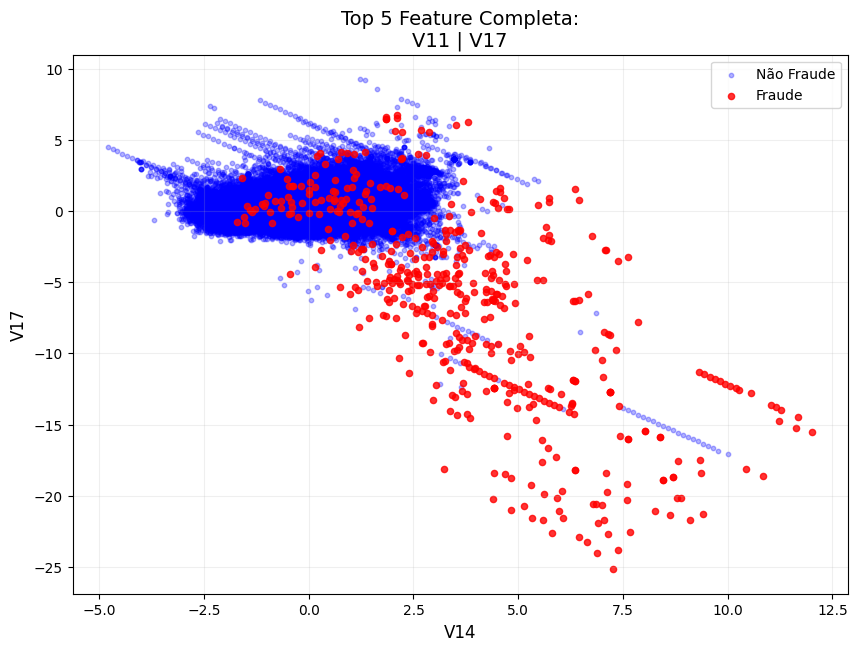

In [46]:
posicao_rank = 5
# GRÁFICO 2D
plt.figure(figsize=(10, 7))

# NÃO FRAUDE
plt.scatter(

    df[df['status_fraude'] == 0][x5],
    df[df['status_fraude'] == 0][y5],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df[df['status_fraude'] == 1][x5],
    df[df['status_fraude'] == 1][y5],

    color='red',
    alpha=0.8,
    s=20,
    label='Fraude'

)

# TÍTULO
plt.title(
    f'Top 5 Feature Completa:\n{feature_top5}',
    fontsize=14
)

plt.xlabel(x1, fontsize=12)
plt.ylabel(y1, fontsize=12)

# LEGENDA
plt.legend()

# GRID
plt.grid(alpha=0.2)

# SHOW
plt.show()

### T-NSE


Top 5: V11 | V17
X = V11
Y = V17


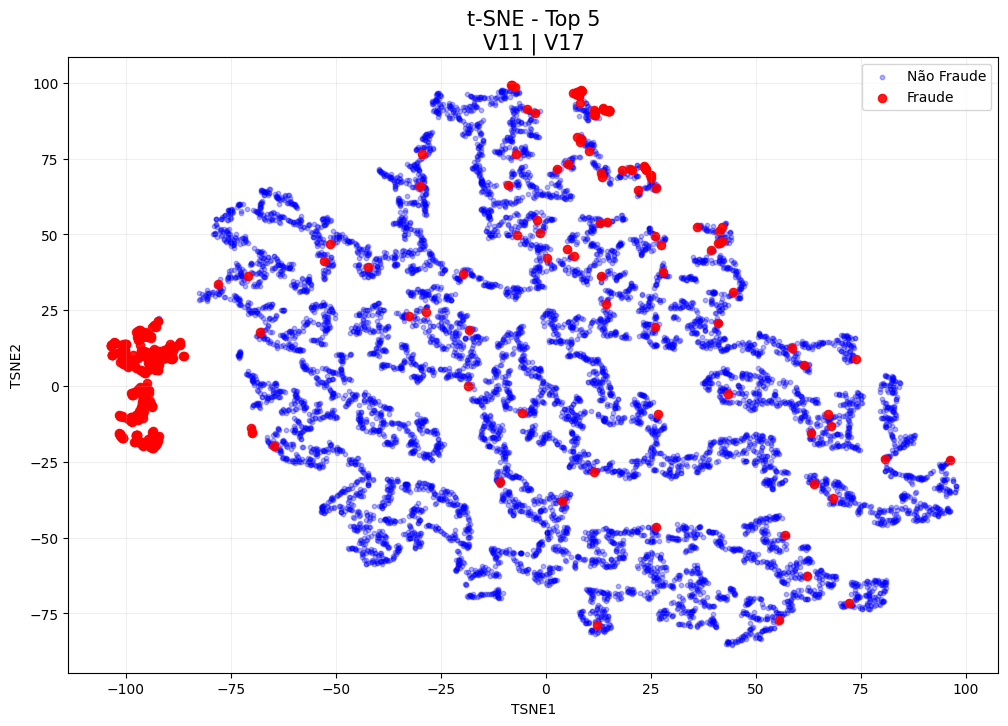

In [54]:

posicao_rank = 5

# =========================================================
# CARREGAR RANKING
# =========================================================

df_rank = pd.read_csv('2x2visu_scores.csv')

# =========================================================
# PEGAR FEATURE DA POSIÇÃO ESCOLHIDA
# =========================================================

feature_escolhida = df_rank.iloc[
    posicao_rank - 1
]['Features']

# =========================================================
# EXTRAIR FEATURES
# =========================================================

x1, y1 = feature_escolhida.split('|')

x1 = x1.strip()
y1 = y1.strip()

# =========================================================
# PRINT
# =========================================================

print(f'\nTop {posicao_rank}: {feature_escolhida}')
print(f'X = {x1}')
print(f'Y = {y1}')

# =========================================================
# DATASET
# =========================================================

df = pd.read_csv('creditcard.csv')

# =========================================================
# FRAUDES
# =========================================================

fraudes = df[
    df['status_fraude'] == 1
]

# =========================================================
# SAMPLE NÃO FRAUDES
# =========================================================

nao_fraudes = df[
    df['status_fraude'] == 0
].sample(

    n=10000,
    random_state=42

)

# =========================================================
# CONCATENAR
# =========================================================

df_tsne = pd.concat([

    fraudes,
    nao_fraudes

])

# =========================================================
# FEATURES
# =========================================================

X = df_tsne[[x1, y1]]

y = df_tsne['status_fraude']

# =========================================================
# ESCALONAMENTO
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================================================
# TSNE
# =========================================================

tsne = TSNE(

    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42

)

X_tsne = tsne.fit_transform(X_scaled)

# =========================================================
# DATAFRAME FINAL
# =========================================================

df_plot = pd.DataFrame({

    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Fraude': y.values

})

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(12, 8))

# NÃO FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 0
    ]['TSNE2'],

    color='blue',
    alpha=0.3,
    s=10,
    label='Não Fraude'

)

# FRAUDE
plt.scatter(

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE1'],

    df_plot[
        df_plot['Fraude'] == 1
    ]['TSNE2'],

    color='red',
    alpha=0.9,
    s=35,
    label='Fraude'

)

# =========================================================
# TÍTULO
# =========================================================

plt.title(

    f't-SNE - Top {posicao_rank}\n'
    f'{feature_escolhida}',

    fontsize=15

)

plt.xlabel('TSNE1')
plt.ylabel('TSNE2')

# =========================================================
# LEGENDA
# =========================================================

plt.legend()

# =========================================================
# GRID
# =========================================================

plt.grid(alpha=0.2)

# =========================================================
# SHOW
# =========================================================

plt.show()